In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [4]:
import os

# Try to read the CSV file. If the previous `ls` command shows the file, uncomment and use the correct path.
folder_path = '/content/gdrive/MyDrive/Time series Projet/data/separted'
path_x_train = f'{folder_path}/X_train.csv'
path_y_train = f'{folder_path}/y_train.csv'
path_x_test = f'{folder_path}/X_test.csv'
path_y_test = f'{folder_path}/y_test.csv'
df_x_train = pd.read_csv(path_x_train)
df_y_train = pd.read_csv(path_y_train)
df_x_test = pd.read_csv(path_x_test)
df_y_test = pd.read_csv(path_y_test)
df = pd.read_csv('/content/gdrive/MyDrive/Time series Projet/data/merged_tourism_data_final.csv')
df=pd.read_csv('/content/gdrive/MyDrive/Time series Projet/data/merged_tourism_data_final.csv')


In [5]:
import pandas as pd
from sklearn.impute import SimpleImputer

# 1. Extraire le mois depuis la colonne 'Date' du DataFrame original 'df'
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# 2. Aligner les mois avec df_x_train et df_x_test
# On suppose que df_x_train sont les n premiers mois et df_x_test les n derniers
train_len = len(df_x_train)
df_x_train['Month'] = df['Month'].iloc[:train_len].values
df_x_test['Month'] = df['Month'].iloc[-len(df_x_test):].values

# 3. Supprimer la colonne 'GDP_Construction_lag1' (souvent vide)
columns_to_drop = ['GDP_Construction_lag1']
df_x_train = df_x_train.drop(columns=columns_to_drop, errors='ignore')
df_x_test = df_x_test.drop(columns=columns_to_drop, errors='ignore')

# 4. Remplacer les NaN par la moyenne
imputer_mean = SimpleImputer(strategy='mean')

# Transformation et reconstruction des DataFrames pour garder les noms de colonnes
df_x_train = pd.DataFrame(imputer_mean.fit_transform(df_x_train), columns=df_x_train.columns)
df_x_test = pd.DataFrame(imputer_mean.transform(df_x_test), columns=df_x_test.columns)

print("Colonne 'Month' ajout	e, 'GDP_Construction_lag1' supprim	e et valeurs manquantes imput	es.")
display(df_x_train.head())

Colonne 'Month' ajout	e, 'GDP_Construction_lag1' supprim	e et valeurs manquantes imput	es.


,lags_1,lags_2,lags_12,roll_mean_3,roll_mean_6,roll_mean_12,roll_std_3,roll_std_6,roll_std_12,growth_yoy,...,saison_1,saison_2,saison_3,Oil_price_lag1,FDI_lag1,Poverty_rate_lag1,REER_lag1,is_covid,cdm_event,Month
0,633422.177994,632063.534202,602697.916667,633854.168306,630143.183946,619180.41088,98558.954377,145414.065987,171588.593167,6.867042,...,0.0,0.0,0.0,55.758226,1.957250e+09,9.667215,103.919218,0.0,0.0,1.0
1,165120.000000,632063.534202,602697.916667,633854.168306,630143.183946,619180.41088,98558.954377,145414.065987,171588.593167,6.867042,...,0.0,0.0,0.0,17.015000,3.347683e+08,15.500000,109.375670,0.0,0.0,2.0
2,165120.000000,165120.000000,602697.916667,633854.168306,630143.183946,619180.41088,98558.954377,145414.065987,171588.593167,6.867042,...,1.0,0.0,0.0,17.050000,3.366899e+08,15.542466,109.404721,0.0,0.0,3.0
3,220160.000000,165120.000000,602697.916667,183466.666667,630143.183946,619180.41088,31777.358816,145414.065987,171588.593167,6.867042,...,1.0,0.0,0.0,16.850000,3.384256e+08,15.580822,109.430960,0.0,0.0,4.0
4,247680.000000,220160.000000,602697.916667,210986.666667,630143.183946,619180.41088,42037.494375,145414.065987,171588.593167,6.867042,...,1.0,0.0,0.0,18.135738,3.403472e+08,15.623288,109.460011,0.0,0.0,5.0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Initialize Imputer (e.g., with mean strategy)
imputer = SimpleImputer(strategy='mean')

# Fit imputer on df_x_train and transform both df_x_train and df_x_test
# Convert to numpy arrays for imputation, then back to DataFrame if needed later
df_x_train_imputed = imputer.fit_transform(df_x_train)
df_x_test_imputed = imputer.transform(df_x_test)

# Initialize and apply StandardScaler
scaler = StandardScaler()

# Fit and Transform on imputed training data
x_train_scaled = scaler.fit_transform(df_x_train_imputed)

# Transform only on imputed test data
x_test_scaled = scaler.transform(df_x_test_imputed)

print("NaN values handled by imputation, and data scaled.")
print(f"Shape of x_train_scaled: {x_train_scaled.shape}")
print(f"Shape of x_test_scaled: {x_test_scaled.shape}")

# Note: This cell only handles scaling of X. If y (target) scaling is needed for specific models,
# it should be done separately, similar to how it was done for df_y_train and df_y_test in the original notebook setup if they were meant to be scaled.

NaN values handled by imputation, and data scaled.
Shape of x_train_scaled: (311, 24)
Shape of x_test_scaled: (39, 24)


In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Vos données préparées (comme dans votre code)
X_train_simple = x_train_scaled[:, 0].reshape(-1, 1)
X_test_simple = x_test_scaled[:, 0].reshape(-1, 1)
y_train_simple = df_y_train
y_test_simple = df_y_test

# 1. Initialiser le modèle Ridge (Régression Linéaire avec régularisation)
ridge_model = Ridge()

# 2. Définir la "grille" d'hyperparamètres à tester
# - alpha : paramètre clé de la régularisation (plus il est grand, plus le modèle est contraint)
# - fit_intercept : tester avec ou sans l'ordonnée à l'origine
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False]
}

# 3. Configurer le GridSearchCV
# scoring : on utilise l'erreur quadratique moyenne négative (sklearn cherche toujours à maximiser, d'où le négatif)
# cv : nombre de plis pour la validation croisée (ex: cv=3 ou cv=5).
# Attention : Si vous avez très peu de données, mettez cv=2 ou cv=3.
grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1 # Utilise tous les cœurs de votre processeur
)

# 4. Entraîner le Grid Search (il va tester toutes les combinaisons)
print("Recherche des meilleurs hyperparamètres en cours...")
grid_search.fit(X_train_simple, y_train_simple)

# 5. Extraire le meilleur modèle trouvé par la grille
best_model = grid_search.best_estimator_

print(f"\n--- Meilleurs Hyperparamètres Trouvés ---")
print(grid_search.best_params_)

# 6. Faire des prédictions avec le meilleur modèle
y_pred = best_model.predict(X_test_simple)

# 7. Évaluer le meilleur modèle
r2_best = r2_score(y_test_simple, y_pred)
mse_best = mean_squared_error(y_test_simple, y_pred)

print(f"\n--- Performances du Meilleur Modèle ---")
print(f"R-squared: {r2_best:.4f}")
print(f"Mean Squared Error: {mse_best:.2f}")

# Afficher les coefficients du meilleur modèle
print(f"\nCoefficient (lags_1): {best_model.coef_[0]:.2f}")
print(f"Intercept: {best_model.intercept_[0]:.2f}")

Recherche des meilleurs hyperparamètres en cours...

--- Meilleurs Hyperparamètres Trouvés ---
{'alpha': 0.001, 'fit_intercept': True}

--- Performances du Meilleur Modèle ---
R-squared: -0.0366
Mean Squared Error: 158236548365.37

Coefficient (lags_1): 301311.73
Intercept: 635164.74


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Define X and y for multiple linear regression using the scaled data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = x_train_scaled, x_test_scaled, df_y_train, df_y_test

# Initialisation du modèle Ridge et recherche des meilleurs hyperparamètres (alpha et fit_intercept) via GridSearchCV
multi_lr_model = GridSearchCV(Ridge(), param_grid={'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 'fit_intercept': [True, False]}, scoring='neg_mean_squared_error', cv=3, n_jobs=-1)

multi_lr_model.fit(X_train_multi, y_train_multi)
y_pred_multi = multi_lr_model.predict(X_test_multi)

r2_multi = r2_score(y_test_multi, y_pred_multi)
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)

print(f"\nMultiple Linear Regression (Ridge) Model Performance via GridSearch:")
print(f"Meilleurs paramètres trouvés : {multi_lr_model.best_params_}")
print(f"R-squared: {r2_multi:.4f}")
print(f"Mean Squared Error: {mse_multi:.2f}")


Multiple Linear Regression (Ridge) Model Performance via GridSearch:
Meilleurs paramètres trouvés : {'alpha': 1.0, 'fit_intercept': True}
R-squared: 0.7826
Mean Squared Error: 33190025319.38


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Prepare data
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = x_train_scaled, x_test_scaled, df_y_train, df_y_test

ridge = Ridge()

# Define param_grid_ridge (reusing param_grid from the simple Ridge model if applicable)
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False]
}

# Set up Grid Search using the correct data variables
ridge_cv = GridSearchCV(estimator=ridge, param_grid=param_grid_ridge, cv=5, scoring='r2')

# Fit the model using the correct data variables
ridge_cv.fit(X_train_ridge, y_train_ridge)

# Results
print(f"Best Alpha: {ridge_cv.best_params_['alpha']}")
print(f"Best CV R-squared: {ridge_cv.best_score_:.4f}")

# Test set performance
y_pred_ridge = ridge_cv.predict(X_test_ridge)
print(f"Test R-squared: {r2_score(y_test_ridge, y_pred_ridge):.4f}")

Best Alpha: 1.0
Best CV R-squared: 0.7648
Test R-squared: 0.7826


In [10]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Removed: X_svr = df_ml[FEATURES_ML] as df_ml is not defined
# Removed: y_svr = df_ml[TARGET] as df_ml is not defined

X_train_svr, X_test_svr, y_train_svr, y_test_svr = x_train_scaled , x_test_scaled, df_y_train, df_y_test


svr_models = []
r2_scores_svr = []

C_values = [0.1, 0.001, 1, 5, 10]
epsilon_values = [0.1, 0.001, 1, 5, 10]

for c_val in C_values:
  for e_val in epsilon_values:
    # Initialize SVR with current c_val and e_val
    svr = SVR(kernel='rbf', C=c_val, epsilon=e_val)

    # Train the model
    svr.fit(X_train_svr, y_train_svr)

    # Make predictions on the test set
    y_pred_svr = svr.predict(X_test_svr)

    # Evaluate the model
    r2 = r2_score(y_test_svr, y_pred_svr)

    # Store model and R-squared score
    svr_models.append({'C': c_val, 'epsilon': e_val, 'model': svr, 'r2': r2})
    r2_scores_svr.append(r2)

    print(f"SVR with C={c_val}, epsilon={e_val} | R-squared: {r2:.4f}")

# Optionally, find the best model
best_svr_model_info = max(svr_models, key=lambda item: item['r2'])
print(f"\nBest SVR Model: C={best_svr_model_info['C']}, epsilon={best_svr_model_info['epsilon']}, R-squared: {best_svr_model_info['r2']:.4f}")

SVR with C=0.1, epsilon=0.1 | R-squared: -4.7430
SVR with C=0.1, epsilon=0.001 | R-squared: -4.7430
SVR with C=0.1, epsilon=1 | R-squared: -4.7430
SVR with C=0.1, epsilon=5 | R-squared: -4.7430
SVR with C=0.1, epsilon=10 | R-squared: -4.7429
SVR with C=0.001, epsilon=0.1 | R-squared: -4.7430
SVR with C=0.001, epsilon=0.001 | R-squared: -4.7430
SVR with C=0.001, epsilon=1 | R-squared: -4.7430
SVR with C=0.001, epsilon=5 | R-squared: -4.7430
SVR with C=0.001, epsilon=10 | R-squared: -4.7429
SVR with C=1, epsilon=0.1 | R-squared: -4.7430
SVR with C=1, epsilon=0.001 | R-squared: -4.7430
SVR with C=1, epsilon=1 | R-squared: -4.7430
SVR with C=1, epsilon=5 | R-squared: -4.7429
SVR with C=1, epsilon=10 | R-squared: -4.7429
SVR with C=5, epsilon=0.1 | R-squared: -4.7428
SVR with C=5, epsilon=0.001 | R-squared: -4.7428
SVR with C=5, epsilon=1 | R-squared: -4.7428
SVR with C=5, epsilon=5 | R-squared: -4.7428
SVR with C=5, epsilon=10 | R-squared: -4.7427
SVR with C=10, epsilon=0.1 | R-squared: -4

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [11]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb


X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb =  x_train_scaled , x_test_scaled, df_y_train, df_y_test
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500],
    'subsample': [0.8, 1.0]
}

# Initialize the XGBRegressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Fit the grid search
print("Starting Grid Search...")
grid_search.fit(X_train_xgb, y_train_xgb)

# Print best parameters and score
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation R-squared: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_xgb)
r2_grid = r2_score(y_test_xgb, y_pred_grid)
print(f"Final Test R-squared (Best Model): {r2_grid:.4f}")

Starting Grid Search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
Best Cross-Validation R-squared: 0.2773
Final Test R-squared (Best Model): 0.0106


In [12]:
# Conversion du DataFrame en liste via numpy
print(df_x_train)

           lags_1        lags_2        lags_12   roll_mean_3   roll_mean_6  \
0    6.334222e+05  6.320635e+05  602697.916667  6.338542e+05  6.301432e+05   
1    1.651200e+05  6.320635e+05  602697.916667  6.338542e+05  6.301432e+05   
2    1.651200e+05  1.651200e+05  602697.916667  6.338542e+05  6.301432e+05   
3    2.201600e+05  1.651200e+05  602697.916667  1.834667e+05  6.301432e+05   
4    2.476800e+05  2.201600e+05  602697.916667  2.109867e+05  6.301432e+05   
..            ...           ...            ...           ...           ...   
306  2.088388e+06  1.139321e+06  602697.916667  1.342963e+06  9.117528e+05   
307  1.310751e+06  2.088388e+06  602697.916667  1.512820e+06  1.076666e+06   
308  9.007240e+05  1.310751e+06  602697.916667  1.433288e+06  1.137825e+06   
309  1.117503e+06  9.007240e+05  602697.916667  1.109659e+06  1.226311e+06   
310  8.974080e+05  1.117503e+06  602697.916667  9.718783e+05  1.242349e+06   

     roll_mean_12     roll_std_3     roll_std_6    roll_std_12 

In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# --- ETAPE 1 : Transformer la cible en difference ---
y_train_diff = df_y_train.diff().dropna()
y_test_diff = df_y_test.diff().dropna()

# --- ETAPE 2 : Aligner les features (X) avec la nouvelle cible ---
# x_train_scaled et x_test_scaled perdent leur premiere ligne
X_train_diff = x_train_scaled[1:]
X_test_diff = x_test_scaled[1:]

# --- ETAPE 3 : Configuration du Grid Search pour XGBoost ---
# On definit la grille d'hyperparametres a tester
param_grid = {
    'max_depth': [2, 3, 4],       # Arbres peu profonds pour eviter l'overfitting
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'subsample': [0.7, 0.8, 1.0], # Echantillonnage pour plus de robustesse
    'reg_alpha': [0, 0.1, 1],     # Penalisation L1 (Lasso)
    'reg_lambda': [1, 5, 10]      # Penalisation L2 (Ridge)
}

# Initialisation du modele de base
xgb_base = xgb.XGBRegressor(random_state=42)

# Configuration de GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,            # Validation croisee a 3 plis (adapte aux petits datasets)
    scoring='r2',    # On cherche a maximiser le R2 sur les differences
    verbose=1,
    n_jobs=-1
)

print("Recherche des meilleurs hyperparametres en cours...")
grid_search.fit(X_train_diff, y_train_diff)

print(f"\nMeilleurs parametres trouves : {grid_search.best_params_}")

# On recupere le meilleur modele trouve par la grille
best_xgb_model = grid_search.best_estimator_

# --- ETAPE 4 : Predictions sur la difference avec le meilleur modele ---
y_pred_diff = best_xgb_model.predict(X_test_diff)

# --- ETAPE 5 : Reconstruire les predictions finales ---
# On utilise la valeur reelle a (t-1) pour predire t
valeurs_ref = df_y_test.iloc[:-1].values.flatten()

# Reconstitution : Valeur reelle a t-1 + difference predite pour t
y_pred_finales = valeurs_ref + y_pred_diff

# --- ETAPE 6 : Evaluation finale ---
y_true_aligned = df_y_test.iloc[1:].values.flatten()

r2_final = r2_score(y_true_aligned, y_pred_finales)
print(f"\nNouveau Score R2 de XGBoost (apres GridSearch et reconstruction) : {r2_final:.4f}")

Recherche des meilleurs hyperparametres en cours...
Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Meilleurs parametres trouves : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'reg_alpha': 0, 'reg_lambda': 10, 'subsample': 0.7}

Nouveau Score R2 de XGBoost (apres GridSearch et reconstruction) : 0.1329


      Model          RMSE     MAPE           MAE        R2
  Simple LR 397789.578000 0.197125 305278.901922 -0.036597
Multiple LR 182181.297941 0.081740 127946.269320  0.782574
      Ridge 182181.297941 0.081740 127946.269320  0.782574
        SVR 936265.191953 0.566599 850843.809568 -4.742501
    XGBoost 388627.046539 0.180666 291591.958333  0.010606


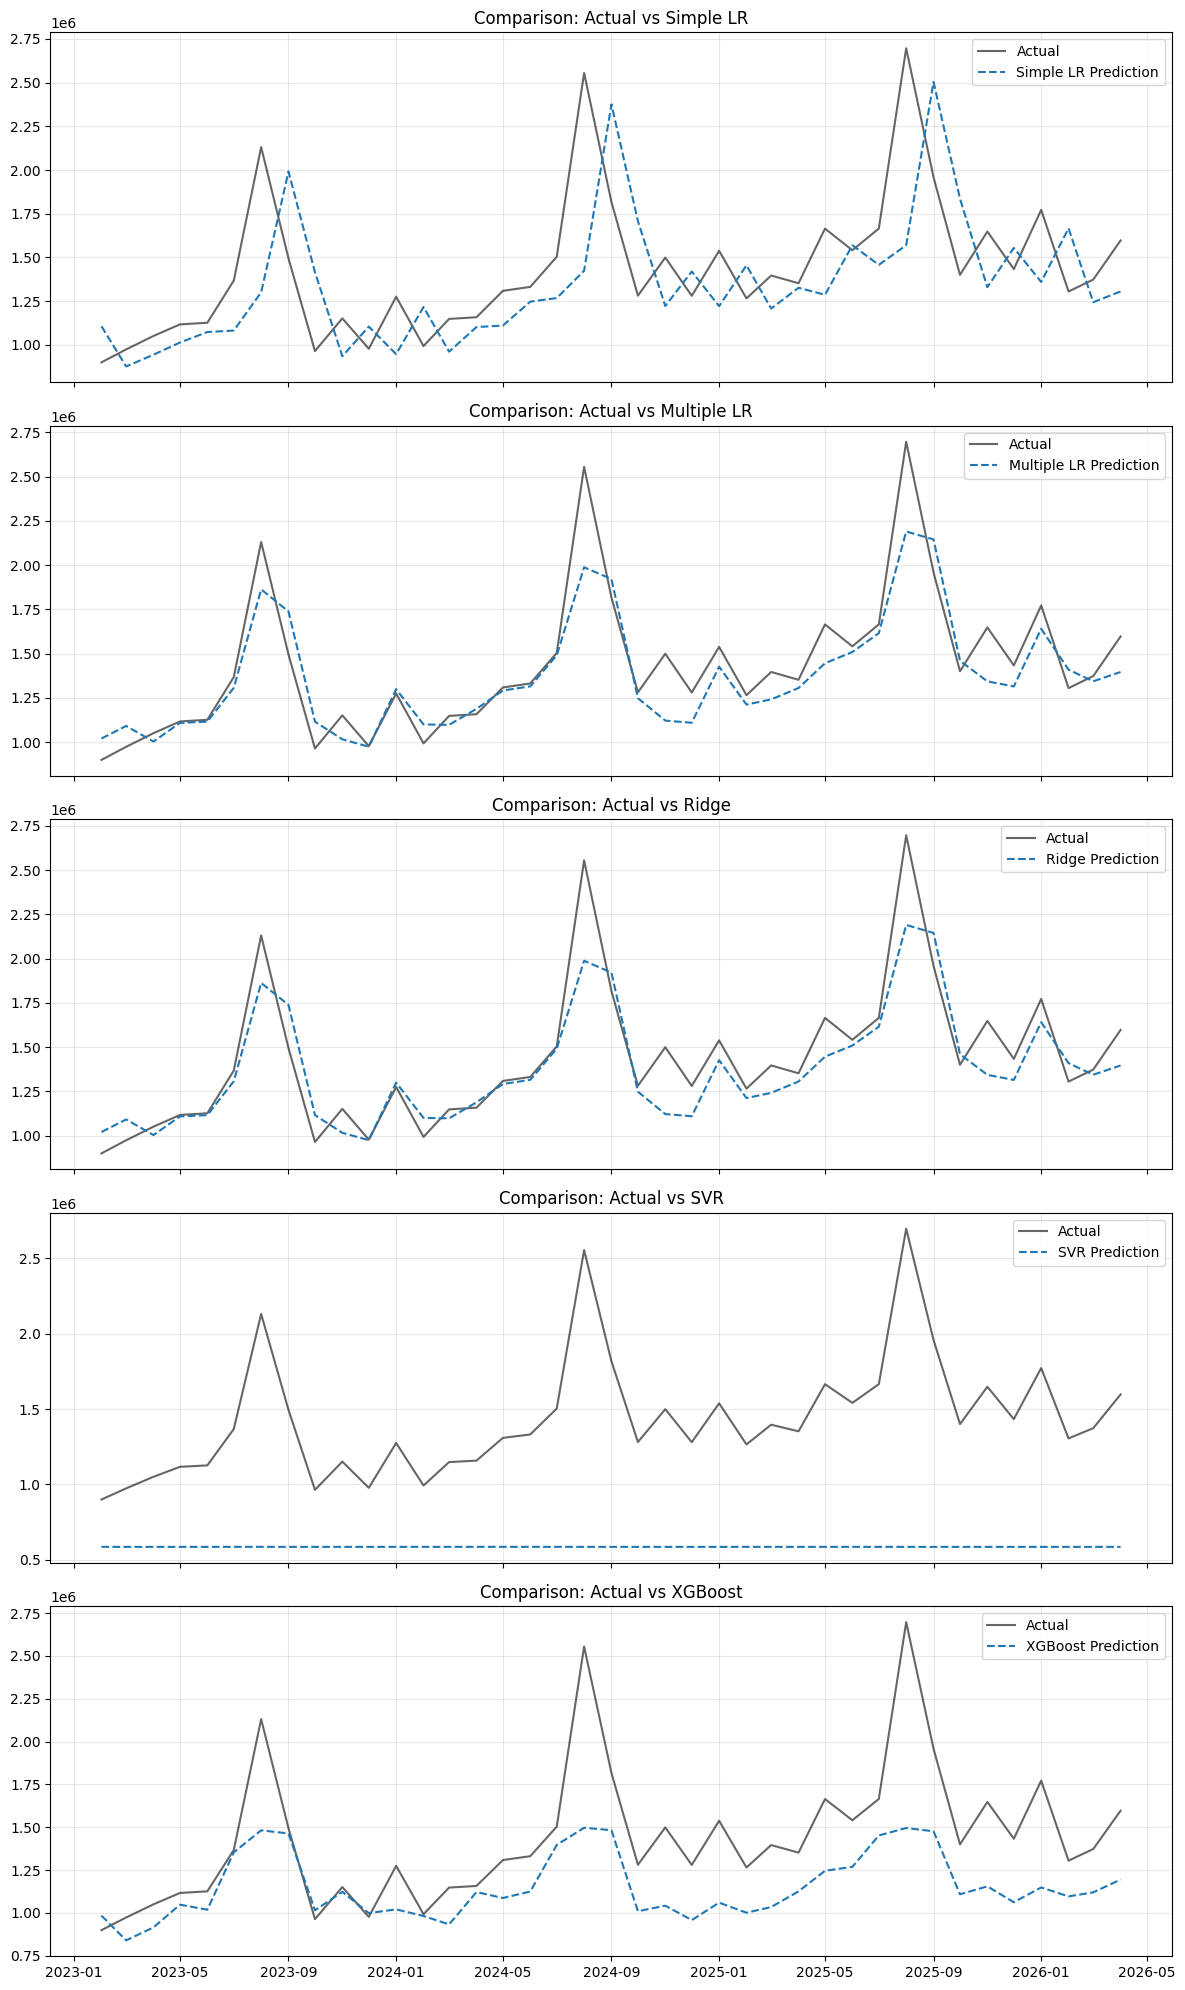

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def evaluate_predictions(y_true, y_pred):
    y_true, y_pred = np.array(y_true).flatten(), np.array(y_pred).flatten()
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

# Redéfinition sécurisée des prédictions à partir des modèles entraînés
# Simple LR (depuis la cellule 1VH3nochiQUR)
y_pred_slr = grid_search.best_estimator_.predict(x_test_scaled[:, 0].reshape(-1, 1))

models_preds = {
    'Simple LR': y_pred_slr,
    'Multiple LR': y_pred_multi,
    'Ridge': y_pred_ridge,
    'SVR': best_svr_model_info['model'].predict(X_test_svr),
    'XGBoost': y_pred_grid
}

results = []
for name, pred in models_preds.items():
    metrics = evaluate_predictions(df_y_test, pred)
    metrics['Model'] = name
    results.append(metrics)

df_results_final = pd.DataFrame(results)[['Model', 'RMSE', 'MAPE', 'MAE', 'R2']]
print("--- Tableau Comparatif des Modèles ---")
print(df_results_final.to_string(index=False))

test_dates = pd.to_datetime(df['Date']).iloc[-len(df_y_test):].values
fig, axes = plt.subplots(len(models_preds), 1, figsize=(12, 4 * len(models_preds)), sharex=True)

for i, (name, pred) in enumerate(models_preds.items()):
    axes[i].plot(test_dates, df_y_test.values.flatten(), label='Réel', color='black', alpha=0.5)
    axes[i].plot(test_dates, pred.flatten(), label=f'Prédit ({name})', linestyle='--', color='red')
    axes[i].set_title(f'Performance: {name}')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

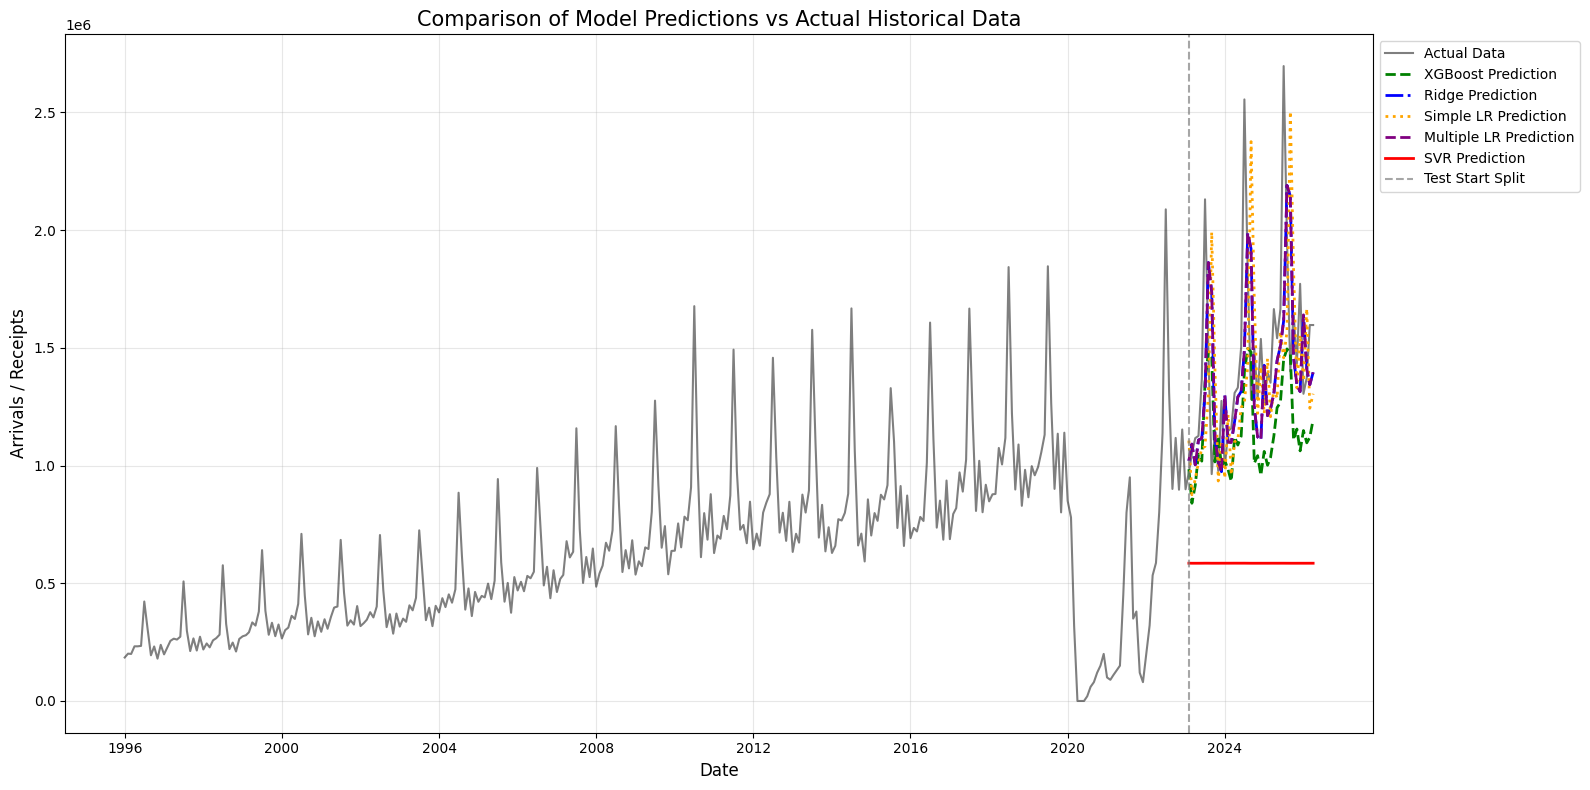

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Prepare df_plot from the original 'df'
# We use the main merged dataset 'df' loaded in cell KLUY8H1Sds9c
df_plot = df.copy()
df_plot['Date'] = pd.to_datetime(df_plot['Date'])
df_plot = df_plot.sort_values('Date')

# The target in 'df' is 'InterTourismeReceipts' (renamed to Arrivals for the plot)
df_plot.rename(columns={'Arrivals': 'Arrivals'}, inplace=True)

# 2. Map predictions to their corresponding dates
# We assume the test set (last 39 rows) corresponds to the end of the time series
test_size = len(df_y_test)
test_dates = df_plot['Date'].iloc[-test_size:]

plt.figure(figsize=(16, 8))

# Plot Actual values (Historical)
plt.plot(df_plot['Date'], df_plot['Arrivals'], label='Actual Data', color='black', linewidth=1.5, alpha=0.5)

# Define model predictions to plot
# We check for existence of prediction variables from previous cells
models_to_plot = [
    ('XGBoost', y_pred_grid, 'green', '--'),
    ('Ridge', y_pred_ridge, 'blue', '-.'),
    ('Simple LR', y_pred, 'orange', ':'),
    ('Multiple LR', y_pred_multi, 'purple', '--'),
    ('SVR', best_svr_model_info['model'].predict(X_test_svr), 'red', '-')
]

for name, pred, color, style in models_to_plot:
    # Ensure prediction is a 1D array for plotting
    y_values = pred.flatten()
    plt.plot(test_dates, y_values, label=f'{name} Prediction', color=color, linestyle=style, linewidth=2)

# Highlight the start of the test set
plt.axvline(x=test_dates.iloc[0], color='gray', linestyle='--', alpha=0.7, label='Test Start Split')

plt.title('Comparison of Model Predictions vs Actual Historical Data', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Arrivals / Receipts', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def get_metrics(y_true, y_pred):
    # Assurer que y_true est 1D pour les calculs
    y_true_arr = np.array(y_true).flatten()
    y_pred_arr = np.array(y_pred).flatten()
    mse = mean_squared_error(y_true_arr, y_pred_arr)
    return {
        'R2': r2_score(y_true_arr, y_pred_arr),
        'MSE': mse,
        'MAE': mean_absolute_error(y_true_arr, y_pred_arr),
        'RMSE': np.sqrt(mse)
    }

# Calcul des métriques pour chaque modèle avec les bons noms de variables
metrics_xgb = get_metrics(y_test_xgb, y_pred_grid)
metrics_ridge = get_metrics(y_test_ridge, y_pred_ridge)
metrics_slr = get_metrics(y_test_simple, y_pred)
metrics_mlr = get_metrics(y_test_multi, y_pred_multi)
metrics_svr = get_metrics(y_test_svr, best_svr_model_info['model'].predict(X_test_svr))

# Construction du tableau final
comparison_data = {
    'Modèle': ['XGBoost (GridSearch)', 'Ridge Regression', 'Simple LR', 'Multiple LR', 'SVR'],
    'R2': [metrics_xgb['R2'], metrics_ridge['R2'], metrics_slr['R2'], metrics_mlr['R2'], metrics_svr['R2']],
    'MSE': [metrics_xgb['MSE'], metrics_ridge['MSE'], metrics_slr['MSE'], metrics_mlr['MSE'], metrics_svr['MSE']],
    'MAE': [metrics_xgb['MAE'], metrics_ridge['MAE'], metrics_slr['MAE'], metrics_mlr['MAE'], metrics_svr['MAE']],
    'RMSE': [metrics_xgb['RMSE'], metrics_ridge['RMSE'], metrics_slr['RMSE'], metrics_mlr['RMSE'], metrics_svr['RMSE']]
}

df_results = pd.DataFrame(comparison_data).sort_values(by='R2', ascending=False)

# Sauvegarde du tableau en CSV dans Drive
df_results.to_csv('/content/gdrive/MyDrive/Time series Projet/data/model_performance_metrics_ML.csv', index=False)

print("Tableau des performances sauvegardé.")
display(df_results)

Tableau des performances sauvegardé.


,Modèle,R2,MSE,MAE,RMSE
1,Ridge Regression,0.782574,3.319003e+10,127946.269320,182181.297941
3,Multiple LR,0.782574,3.319003e+10,127946.269320,182181.297941
0,XGBoost (GridSearch),0.010606,1.510310e+11,291591.958333,388627.046539
2,Simple LR,-0.036597,1.582365e+11,305278.901922,397789.578000
4,SVR,-4.742501,8.765925e+11,850843.809568,936265.191953
